# YOLO11-S + DCT + Attention Gates + 3×Neck CBAM: Wildfire Smoke & Fire Detection
**Architecture:** Kitchen-sink ablation — three non-redundant mechanisms targeting distinct architectural points:
1. **MultiSpectralAttention (DCT)** at L10 — frequency-domain channel attention after SPPF (512ch, 20×20)
2. **AttentionGate × 2** on FPN skip connections — gates P4 skip (L6, 256ch) and P3 skip (L4, 256ch) before neck Concat
3. **CBAM × 3** after each Detect-scale C3k2 — spatial+channel refinement at P3/P4/P5 (128/256/512ch)

**Hypothesis:** 3×Neck CBAM recall collapse (82.5%) in isolation happened because neck CBAMs operated on
haze-contaminated features from raw skips. DCT cleans the backbone representation; AG gates the skips.
Neck CBAMs then see cleaner features and suppress FPs without destroying recall.

**Target:** FP rate approaching 42–50% with recall ≥ 88%.

**Datasets:** D-Fire + NEMO + PyroNear (pyro-sdis) → unified corpus of ~55,698 images
**Hardware:** Kaggle T4 | **Framework:** Ultralytics YOLO11, PyTorch
**Weight init:** Cold start from factory `yolo11s.pt` — 6 new modules random-init, all vanilla layers warm-started

---
## 1. Setup

In [1]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
import cv2

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
Torch       : 2.10.0+cu128
CUDA        : True
Device      : Tesla T4
Libraries loaded ✅


---
## 2. D-Fire — Load, Filter & Verify

**Source:** `github.com/gaia-solutions-on-demand/DFireDataset` (Kaggle: `sayedgamal99/smoke-fire-detection-yolo`)  
**Size:** 21,527 RGB images, 26,557 bounding boxes — filtered to ~18,700 by rejecting close-up shots  
**Classes:** 0=smoke, 1=fire (author convention)  
**Hard negatives:** ~9,838 images of lamp glare, sun glare, environmental confusion

In [2]:
DFIRE_PATH  = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
CLASS_NAMES = ["smoke", "fire"]
COLORS      = [(0.39, 0.71, 1.0), (1.0, 0.31, 0.0)]

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        lbls = list(lbl_dir.glob("*.txt"))
        print(f"D-Fire {split:5s}: {len(imgs):6d} images | {len(lbls):6d} labels")
    else:
        print(f"D-Fire {split}: path not found")

D-Fire train:  14122 images |  14122 labels
D-Fire val  :   3099 images |   3099 labels
D-Fire test :   4306 images |   4306 labels


In [3]:
def is_distant_shot(label_path, max_box_area=0.40):
    lbl = Path(label_path)
    if not lbl.exists():
        return True
    with open(lbl) as f:
        lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines):
        return True
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area:
            return False
    return True


print("Filtering D-Fire (max box area = 40%)...")
dfire_kept     = {}
dfire_rejected = {}

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept, rejected = [], []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if is_distant_shot(lbl_path):
            kept.append(img_path)
        else:
            rejected.append(img_path)
    dfire_kept[split]     = kept
    dfire_rejected[split] = rejected
    pct = len(rejected) / max(len(kept) + len(rejected), 1) * 100
    print(f"  {split:5s}: kept {len(kept):6d} | rejected {len(rejected):5d} ({pct:.1f}% removed)")

total_kept     = sum(len(v) for v in dfire_kept.values())
total_rejected = sum(len(v) for v in dfire_rejected.values())
print(f"\nTotal kept: {total_kept} | rejected: {total_rejected} "
      f"({total_rejected/(total_kept+total_rejected)*100:.1f}% overall)")

Filtering D-Fire (max box area = 40%)...
  train: kept  12270 | rejected  1852 (13.1% removed)
  val  : kept   2676 | rejected   423 (13.6% removed)
  test : kept   3754 | rejected   552 (12.8% removed)

Total kept: 18700 | rejected: 2827 (13.1% overall)


---
## 3. NEMO — Convert COCO JSON → YOLO

**Source:** `github.com/SayBender/Nemo` (Kaggle: `werus23/nevada-smoke-detection-data`)  
**Size:** 2,934 images, 4,522 labeled smoke bounding boxes  
**Classes:** Smoke only (low/mid/high density → collapsed to class 0)

In [4]:
NEMO_BASE       = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
NEMO_TRAIN_IMGS = f"{NEMO_BASE}/NEMO data/train_images"
NEMO_VAL_IMGS   = f"{NEMO_BASE}/NEMO data/val_images"
NEMO_TRAIN_JSON = f"{NEMO_BASE}/NEMO data/annotation_train.json"
NEMO_VAL_JSON   = f"{NEMO_BASE}/NEMO data/annotation_val.json"
NEMO_2023_IMGS  = f"{NEMO_BASE}/20-23_daytime_images/daytime images"
NEMO_2023_JSON  = f"{NEMO_BASE}/20-23_daytime_label.json"


def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir, smoke_class=0):
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    with open(json_path) as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)
    converted = copied = 0
    for img_id, img_info in img_map.items():
        W, H   = img_info["width"], img_info["height"]
        fname  = Path(img_info["file_name"]).stem
        src    = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists():
            shutil.copy2(src, Path(img_dst_dir) / src.name)
            copied += 1
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            xc, yc = (x + w/2)/W, (y + h/2)/H
            wn, hn = w/W, h/H
            lines.append(f"{smoke_class} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  Converted {converted} labels, copied {copied} images")


print("Converting NEMO train...")
coco_to_yolo(NEMO_TRAIN_JSON, NEMO_TRAIN_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")
print("Converting NEMO val...")
coco_to_yolo(NEMO_VAL_JSON, NEMO_VAL_IMGS,
             "/kaggle/working/nemo_yolo/images/val",
             "/kaggle/working/nemo_yolo/labels/val")
print("Merging 20-23 daytime into train...")
coco_to_yolo(NEMO_2023_JSON, NEMO_2023_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("\nNEMO conversion complete:")
for split in ["train", "val"]:
    imgs = list(Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"))
    print(f"  {split}: {len(imgs)} images | {len(lbls)} labels")

Converting NEMO train...
  Converted 2680 labels, copied 2680 images
Converting NEMO val...
  Converted 250 labels, copied 250 images
Merging 20-23 daytime into train...
  Converted 432 labels, copied 432 images

NEMO conversion complete:
  train: 3112 images | 3112 labels
  val: 250 images | 250 labels


---
## 4. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

**Source:** `pyronear/pyro-sdis` on HuggingFace (public, no token required)  
**Size:** 33,636 images | Smoke only (class 0) | ~16% hard negatives (empty label files)  
**Camera setup:** Fixed outdoor cameras from SDIS French fire brigade

In [5]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

for split_name, split in [("Train", ds["train"]), ("Val", ds["val"])]:
    has_smoke = sum(1 for s in split if s["annotations"] and s["annotations"].strip())
    no_smoke  = len(split) - has_smoke
    print(f"\n{split_name}:")
    print(f"  Smoke positives  : {has_smoke}")
    print(f"  Hard negatives   : {no_smoke} ({no_smoke/len(split):.1%})")

Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099

Train:
  Smoke positives  : 24792
  Hard negatives   : 4745 (16.1%)

Val:
  Smoke positives  : 3345
  Hard negatives   : 754 (18.4%)


In [6]:
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)


def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")


print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")

Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


---
## 5. Merge → Unified YOLO Dataset

In [7]:
UNIFIED = "/kaggle/working/unified_dataset"

for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

print("Copying D-Fire (filtered)...")
for split in ["train", "val", "test"]:
    for img_path in dfire_kept[split]:
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists():
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")
print("  D-Fire ✅")

print("Copying NEMO...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/nemo_{img.name}")
    for lbl in Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/nemo_{lbl.name}")
print("  NEMO ✅")

print("Copying PyroNear...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/pyro_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/pyro_{img.name}")
    for lbl in Path(f"/kaggle/working/pyro_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/pyro_{lbl.name}")
print("  PyroNear ✅")

print("\n── Unified Dataset ──────────────────────────────")
total = 0
for split in ["train", "val", "test"]:
    imgs = list(Path(f"{UNIFIED}/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"{UNIFIED}/labels/{split}").glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | "
          f"{pos:6d} positive | {neg:5d} negative ({neg/max(len(lbls),1):.1%})")
    total += len(imgs)
print(f"  TOTAL: {total} images")

print("\n── Source Breakdown ────────────────────────────")
for split in ["train", "val"]:
    dfire = len(list(Path(f"{UNIFIED}/images/{split}").glob("dfire_*")))
    nemo  = len(list(Path(f"{UNIFIED}/images/{split}").glob("nemo_*")))
    pyro  = len(list(Path(f"{UNIFIED}/images/{split}").glob("pyro_*")))
    print(f"  {split}: D-Fire={dfire} | NEMO={nemo} | PyroNear={pyro}")

Copying D-Fire (filtered)...
  D-Fire ✅
Copying NEMO...
  NEMO ✅
Copying PyroNear...
  PyroNear ✅

── Unified Dataset ──────────────────────────────
  train:  44919 images |  33716 positive | 11203 negative (24.9%)
  val  :   7025 images |   4896 positive |  2129 negative (30.3%)
  test :   3754 images |   1749 positive |  2005 negative (53.4%)
  TOTAL: 55698 images

── Source Breakdown ────────────────────────────
  train: D-Fire=12270 | NEMO=3112 | PyroNear=29537
  val: D-Fire=2676 | NEMO=250 | PyroNear=4099


---
## 6. Data YAML + Integrity Check

In [8]:
yaml_content = """# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)

# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire



In [9]:
print("── Dataset Integrity Check ────────────────────────────────────")
for split in ["train", "val", "test"]:
    img_dir = Path(f"{UNIFIED}/images/{split}")
    lbl_dir = Path(f"{UNIFIED}/labels/{split}")
    imgs = {p.stem for p in img_dir.glob("*.jpg")}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}
    print(f"\n  {split.upper()}")
    print(f"    Images         : {len(imgs)}")
    print(f"    Labels         : {len(lbls)}")
    print(f"    Matched pairs  : {len(imgs & lbls)}")
    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    if imgs_no_lbl: print(f"    ⚠️  Images w/o label: {len(imgs_no_lbl)}")
    if lbls_no_img: print(f"    ⚠️  Labels w/o image: {len(lbls_no_img)}")
    for prefix in ["dfire", "nemo", "pyro"]:
        n_i = len(list(img_dir.glob(f"{prefix}_*.jpg")))
        n_l = len(list(lbl_dir.glob(f"{prefix}_*.txt")))
        mark = "✅" if n_i == n_l else "⚠️"
        print(f"    {mark} {prefix:8s}: {n_i} imgs | {n_l} lbls")

── Dataset Integrity Check ────────────────────────────────────

  TRAIN
    Images         : 44919
    Labels         : 44919
    Matched pairs  : 44919
    ✅ dfire   : 12270 imgs | 12270 lbls
    ✅ nemo    : 3112 imgs | 3112 lbls
    ✅ pyro    : 29537 imgs | 29537 lbls

  VAL
    Images         : 7025
    Labels         : 7025
    Matched pairs  : 7025
    ✅ dfire   : 2676 imgs | 2676 lbls
    ✅ nemo    : 250 imgs | 250 lbls
    ✅ pyro    : 4099 imgs | 4099 lbls

  TEST
    Images         : 3754
    Labels         : 3754
    Matched pairs  : 3754
    ✅ dfire   : 3754 imgs | 3754 lbls
    ✅ nemo    : 0 imgs | 0 lbls
    ✅ pyro    : 0 imgs | 0 lbls


---
## 7. Module Definitions

Three non-redundant modules for the kitchen-sink experiment:

| Module | Mechanism | Insertion Point | Target |
|--------|-----------|-----------------|--------|
| `MultiSpectralAttention` (DCT) | Fixed 2D DCT filter bank + channel MLP | L10, after SPPF | Frequency-domain: smoke edges vs haze DC |
| `AttentionGate` (×2) | Gated skip connections (Oktay 2018) | L13 (P4 skip), L17 (P3 skip) | Suppress haze texture before skip Concat |
| `CBAM` (×3) | Channel + spatial attention (Woo 2018) | L20/L24/L28 (P3/P4/P5) | Residual FP suppression after clean fusion |

### 7a. MultiSpectralAttention (DCT Frequency Attention)

**Reference:** FcaNet — Qin et al., ICCV 2021 — https://arxiv.org/abs/2012.11879  
**Placement:** L10 — after SPPF (512ch, 20×20 at 640 input)  
**Motivation:** Haze/fog → low-frequency uniform activations. Smoke plumes → mid/high-frequency irregular edges. DCT attention learns which spectral bands activate for smoke vs confounders at the most compressed global feature map.

In [10]:
import math
import torch.nn.functional as F


class MultiSpectralAttention(nn.Module):
    """
    DCT-based channel attention (MultiSpectral Channel Attention).
    Based on FcaNet (Qin et al., ICCV 2021 — https://arxiv.org/abs/2012.11879).
    Adapted for wildfire smoke detection at SPPF output (512ch, 20×20 at 640 input).

    Replaces avg/max pooling with a fixed 2D DCT filter bank.
    MLP learns which frequency bands activate for smoke vs haze.
    Input/output: same shape (B, C, H, W) — drop-in replacement.
    """
    def __init__(self, channels, dct_h=20, dct_w=20, reduction=16):
        super().__init__()
        self.channels = channels
        self.dct_h    = dct_h
        self.dct_w    = dct_w
        self.inp      = channels  # stored for verification cell

        dct_weight = self._build_dct_filter(channels, dct_h, dct_w)
        self.register_buffer('dct_weight', dct_weight)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    @staticmethod
    def _get_dct_components(num_channels, dct_h, dct_w):
        indices = sorted(
            [(u, v) for u in range(dct_h) for v in range(dct_w)],
            key=lambda x: x[0]**2 + x[1]**2
        )
        return indices[:num_channels]

    @staticmethod
    def _build_dct_filter(channels, dct_h, dct_w):
        components = MultiSpectralAttention._get_dct_components(channels, dct_h, dct_w)
        filters = torch.zeros(channels, dct_h, dct_w)
        for c, (u, v) in enumerate(components):
            for h in range(dct_h):
                for w in range(dct_w):
                    filters[c, h, w] = (
                        math.cos(math.pi * u * (2 * h + 1) / (2 * dct_h)) *
                        math.cos(math.pi * v * (2 * w + 1) / (2 * dct_w))
                    )
        norms = filters.reshape(channels, -1).norm(dim=1, keepdim=True).clamp(min=1e-8)
        filters = (filters.reshape(channels, -1) / norms).reshape(channels, dct_h, dct_w)
        return filters

    def forward(self, x):
        B, C, H, W = x.shape
        if H != self.dct_h or W != self.dct_w:
            x_dct = F.adaptive_avg_pool2d(x, (self.dct_h, self.dct_w))
        else:
            x_dct = x
        spectral = (x_dct * self.dct_weight.unsqueeze(0)).sum(dim=(-2, -1))
        attn = self.fc(spectral)
        return x * attn.view(B, C, 1, 1)


# ── Sanity check ──────────────────────────────────────────────────────
_x   = torch.randn(2, 512, 20, 20)
_msa = MultiSpectralAttention(channels=512, dct_h=20, dct_w=20)
_out = _msa(_x)
assert _out.shape == _x.shape
print(f"MultiSpectralAttention — input {tuple(_x.shape)} → output {tuple(_out.shape)}  ✅")
print(f"  dct_h/w : {_msa.dct_h}×{_msa.dct_w}  (SPPF output at 640: 640/32=20)")
print(f"  inp attr: {_msa.inp}  (stored for verification)")
print(f"  params  : {sum(p.numel() for p in _msa.parameters()):,}  (MLP only — DCT filter is a fixed buffer)")

MultiSpectralAttention — input (2, 512, 20, 20) → output (2, 512, 20, 20)  ✅
  dct_h/w : 20×20  (SPPF output at 640: 640/32=20)
  inp attr: 512  (stored for verification)
  params  : 32,768  (MLP only — DCT filter is a fixed buffer)


### 7b. AttentionGate (Gated Skip Connections)

**Reference:** Oktay et al., MICCAI 2018 — https://arxiv.org/abs/1807.06521  
**Placement:** Gate1 at L13 (P4 skip: x=L6 256ch, g=L12 512ch); Gate2 at L17 (P3 skip: x=L4 256ch, g=L16 256ch)  
**Motivation:** Skip connections carry raw backbone haze textures into neck Concat. AGs use the coarser, semantically richer upsampled signal to spatially gate which skip regions to trust.

In [11]:
class AttentionGate(nn.Module):
    """
    Soft attention gate — Oktay et al., MICCAI 2018.
    Gates skip feature x using a coarser gating signal g.

    forward() receives a list [x, g] — Ultralytics multi-from dispatch.
    If g and x have different spatial sizes, g is interpolated to match x.

    Args:
        x_ch    : channels of skip feature (actual, post gw-scale)
        g_ch    : channels of gating signal (actual, post gw-scale)
        inter_ch: bottleneck dim (default: x_ch // 2)
    """
    def __init__(self, x_ch, g_ch, inter_ch=None):
        super().__init__()
        inter_ch     = inter_ch or max(x_ch // 2, 1)
        self.W_x     = nn.Conv2d(x_ch,     inter_ch, kernel_size=1, bias=False)
        self.W_g     = nn.Conv2d(g_ch,     inter_ch, kernel_size=1, bias=False)
        self.psi     = nn.Conv2d(inter_ch, 1,        kernel_size=1, bias=False)
        self.bn      = nn.BatchNorm2d(inter_ch)
        self.relu    = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, inputs):
        x, g = inputs                           # x: skip feat, g: gating signal
        x1   = self.W_x(x)
        g1   = self.W_g(g)
        if g1.shape[2:] != x1.shape[2:]:       # spatial alignment guard
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='nearest')
        attn = self.sigmoid(self.psi(self.relu(self.bn(x1 + g1))))
        return x * attn                         # gated skip, same shape as x


# ── Sanity check ──────────────────────────────────────────────────────
gate_configs = [
    ("Gate1 P4 skip", 256, 512),  # x=L6(256ch), g=L12 upsampled C2PSA(512ch)
    ("Gate2 P3 skip", 256, 256),  # x=L4(256ch), g=L16 upsampled P4-neck(256ch)
]
for label, x_ch, g_ch in gate_configs:
    _x   = torch.randn(2, x_ch, 40, 40)
    _g   = torch.randn(2, g_ch, 40, 40)
    _ag  = AttentionGate(x_ch=x_ch, g_ch=g_ch)
    _out = _ag([_x, _g])
    assert _out.shape == _x.shape
    params = sum(p.numel() for p in _ag.parameters())
    inter  = max(x_ch // 2, 1)
    print(f"AttentionGate {label}  x:{x_ch}ch  g:{g_ch}ch  inter:{inter}ch | "
          f"{tuple(_x.shape)} → {tuple(_out.shape)} | params {params:,} ✅")

AttentionGate Gate1 P4 skip  x:256ch  g:512ch  inter:128ch | (2, 256, 40, 40) → (2, 256, 40, 40) | params 98,688 ✅
AttentionGate Gate2 P3 skip  x:256ch  g:256ch  inter:128ch | (2, 256, 40, 40) → (2, 256, 40, 40) | params 65,920 ✅


### 7c. CBAM (Channel + Spatial Attention)

**Reference:** Woo et al., ECCV 2018  
**Placement:** L20 (P3, 128ch), L24 (P4, 256ch), L28 (P5, 512ch) — after each detection-scale C3k2  
**Motivation:** Residual FP suppression after clean fusion. With DCT+AG cleaning upstream, neck CBAMs operate on cleaner features and can suppress FPs without the recall collapse seen in the 3×Neck isolation ablation (82.5% recall).

In [12]:
class ChannelAttention(nn.Module):
    """
    Channel attention using shared MLP on avg+max pooled features.
    Uses Conv2d(1×1) for the shared MLP so that .in_channels is accessible.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        mx  = self.mlp(self.max_pool(x))
        return self.sigmoid(avg + mx)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x


# ── Sanity check ──────────────────────────────────────────────────────
cbam_configs = [
    ("P3 CBAM", 128),   # after P3 C3k2 (128ch actual, gw=0.50)
    ("P4 CBAM", 256),   # after P4 C3k2 (256ch actual)
    ("P5 CBAM", 512),   # after P5 C3k2 (512ch actual)
]
for label, ch in cbam_configs:
    _x    = torch.randn(2, ch, 4, 4)
    _cbam = CBAM(ch)
    _out  = _cbam(_x)
    assert _out.shape == _x.shape
    params = sum(p.numel() for p in _cbam.parameters())
    mid    = max(ch // 16, 1)
    print(f"CBAM {label}  {ch}ch | in_channels={_cbam.ca.mlp[0].in_channels} | "
          f"{tuple(_x.shape)} → {tuple(_out.shape)} | params {params:,} ✅")

CBAM P3 CBAM  128ch | in_channels=128 | (2, 128, 4, 4) → (2, 128, 4, 4) | params 2,146 ✅
CBAM P4 CBAM  256ch | in_channels=256 | (2, 256, 4, 4) → (2, 256, 4, 4) | params 8,290 ✅
CBAM P5 CBAM  512ch | in_channels=512 | (2, 512, 4, 4) → (2, 512, 4, 4) | params 32,866 ✅


---
## 8. Register All Custom Modules into Ultralytics Runtime

Single-cell direct `__dict__` injection — most reliable across Ultralytics versions. All five classes must be registered before the YAML is parsed.

In [13]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

# Register all five classes via direct __dict__ injection
_CUSTOM_MODULES = {
    'MultiSpectralAttention': MultiSpectralAttention,
    'AttentionGate':          AttentionGate,
    'CBAM':                   CBAM,
    'ChannelAttention':       ChannelAttention,
    'SpatialAttention':       SpatialAttention,
}

for name, cls in _CUSTOM_MODULES.items():
    tasks_mod.__dict__[name] = cls
    ulm.__dict__[name]       = cls
    conv_mod.__dict__[name]  = cls

# Defensive: also patch module_map dict if present (Ultralytics >= 8.x)
patched = False
for attr_name in dir(tasks_mod):
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and 'C2PSA' in str(obj):
        obj.update(_CUSTOM_MODULES)
        print(f"Also patched into tasks_mod.{attr_name} ✅")
        patched = True
        break
if not patched:
    print("module_map dict scan: not found (expected for most Ultralytics versions) ✅")

print("\nAll custom modules registered:")
for name in _CUSTOM_MODULES:
    print(f"  tasks_mod.{name} → {tasks_mod.__dict__[name]}")

# ── Patch parse_model for multi-from custom modules ───────────────────────────
# Ultralytics' parse_model does c2 = ch[f] where f=[skip_idx, gate_idx]
# for any module it doesn't recognise — fails with TypeError in newer versions.
# Fix: when f is a list, use ch[f[0]] (output channels = skip feature channels).
import re as _re, inspect as _inspect
import ultralytics.nn.tasks as _tasks

_pm_src = _inspect.getsource(_tasks.parse_model)
_pm_patched = _re.sub(
    r'(\belse\b\s*:\s*\n\s*)(c2 = ch\[f\])',
    r'\1c2 = ch[f] if isinstance(f, int) else ch[f[0]]',
    _pm_src, count=1
)
if _pm_patched != _pm_src:
    _ns = {}
    exec(compile(_pm_patched, '<parse_model_patched>', 'exec'), {**_tasks.__dict__}, _ns)
    _tasks.parse_model = _ns['parse_model']
    print("parse_model patched: multi-from custom modules supported ✅")
else:
    print("WARNING: patch string not found — check Ultralytics version manually")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
module_map dict scan: not found (expected for most Ultralytics versions) ✅

All custom modules registered:
  tasks_mod.MultiSpectralAttention → <class '__main__.MultiSpectralAttention'>
  tasks_mod.AttentionGate → <class '__main__.AttentionGate'>
  tasks_mod.CBAM → <class '__main__.CBAM'>
  tasks_mod.ChannelAttention → <class '__main__.ChannelAttention'>
  tasks_mod.SpatialAttention → <class '__main__.SpatialAttention'>
parse_model patched: multi-from custom modules supported ✅


---
## 9. Kitchen-Sink YAML — YOLO11-S + DCT + AG×2 + 3×Neck CBAM

### Index arithmetic (6 insertions, max +5 shift vs vanilla)

| Vanilla → New | Module | Why |
|---|---|---|
| L10 → NEW L10 | MultiSpectralAttention [512ch] | DCT at SPPF output |
| L10 → L11 | C2PSA | +1: DCT |
| L11 → L12 | Upsample | +1 |
| — → NEW L13 | AttentionGate Gate1 [256,512] | Gate P4 skip (L6) via upsample (L12) |
| L12 Concat → L14 | Concat([-1,12]) | +2: DCT + AG1 |
| L13 C3k2 → L15 | C3k2 P4 neck | +2 |
| L14 → L16 | Upsample | +2 |
| — → NEW L17 | AttentionGate Gate2 [256,256] | Gate P3 skip (L4) via upsample (L16) |
| L15 Concat → L18 | Concat([-1,16]) | +3: DCT + AG1 + AG2 |
| L16 C3k2 P3 → L19 | C3k2 P3 (128ch) | +3 |
| — → NEW L20 | CBAM [128ch] | P3 neck attention |
| L17 Conv → L21 | Conv stride-2 | +4: DCT + AG1 + AG2 + CBAM-P3 |
| L18 Concat → L22 | Concat([-1,15]) | +4 |
| L19 C3k2 P4 → L23 | C3k2 P4 (256ch) | +4 |
| — → NEW L24 | CBAM [256ch] | P4 neck attention |
| L20 Conv → L25 | Conv stride-2 | +5: + CBAM-P4 |
| L21 Concat → L26 | Concat([-1,11]) | +5 |
| L22 C3k2 P5 → L27 | C3k2 P5 (512ch) | +5 |
| — → NEW L28 | CBAM [512ch] | P5 neck attention |
| Detect([16,19,22]) → L29 | Detect([20,24,28]) | reads CBAM outputs |

**Detect reads from CBAM outputs:** P3 CBAM @ L20, P4 CBAM @ L24, P5 CBAM @ L28.

In [14]:
kitchen_yaml_str = """
# YOLO11-S + DCT Frequency Attention + Attention Gates on FPN Skips + 3×Neck CBAM
#
# References:
#   MultiSpectralAttention : FcaNet — Qin et al., ICCV 2021 (https://arxiv.org/abs/2012.11879)
#   AttentionGate          : Oktay et al., MICCAI 2018 (https://arxiv.org/abs/1807.06521)
#   CBAM                   : Woo et al., ECCV 2018
#
# Architecture (gw=0.50 applied — all ch counts are actual post-scale values):
#
#   Backbone:
#     L0–L9  : vanilla YOLO11-S (64/128/256/512/1024ch)
#     L10    : MultiSpectralAttention [512ch]  ← DCT at SPPF (NEW)
#     L11    : C2PSA [512ch actual]
#
#   Head:
#     L12    : Upsample (512ch)
#     L13    : AttentionGate [6,12]  x=L6(256ch), g=L12(512ch) → 256ch  (Gate1, P4 skip, NEW)
#     L14    : Concat([-1,12])  gated(256) + upsample(512) = 768ch
#     L15    : C3k2 → 256ch actual  (P4 neck feature)
#
#     L16    : Upsample (256ch)
#     L17    : AttentionGate [4,16]  x=L4(256ch), g=L16(256ch) → 256ch  (Gate2, P3 skip, NEW)
#     L18    : Concat([-1,16])  gated(256) + upsample(256) = 512ch
#     L19    : C3k2 → 128ch actual  (P3 output)
#     L20    : CBAM [128ch]                                               (P3 CBAM, NEW)
#
#     L21    : Conv stride-2 (from P3 CBAM, 128ch → 128ch)
#     L22    : Concat([-1,15])  128 + 256 = 384ch
#     L23    : C3k2 → 256ch actual  (P4 output)
#     L24    : CBAM [256ch]                                               (P4 CBAM, NEW)
#
#     L25    : Conv stride-2 (from P4 CBAM, 256ch → 256ch)
#     L26    : Concat([-1,11])  256 + 512 = 768ch
#     L27    : C3k2 → 512ch actual  (P5 output)
#     L28    : CBAM [512ch]                                               (P5 CBAM, NEW)
#
#     L29    : Detect([20, 24, 28])  reads P3/P4/P5 CBAM outputs
#
# Total new layers: 6 (1×DCT + 2×AG + 3×CBAM)
# Total layers    : 30 (vanilla 24 + 6 new)

nc: 2  # smoke=0, fire=1

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]            # 0   P1/2
  - [-1, 1, Conv,  [128, 3, 2]]           # 1   P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]    # 2
  - [-1, 1, Conv,  [256, 3, 2]]           # 3   P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]    # 4   P3 skip (256ch actual)
  - [-1, 1, Conv,  [512, 3, 2]]           # 5   P4/16
  - [-1, 2, C3k2,  [512, True]]           # 6   P4 skip (256ch actual)
  - [-1, 1, Conv,  [1024, 3, 2]]          # 7   P5/32
  - [-1, 2, C3k2,  [1024, True]]          # 8
  - [-1, 1, SPPF,  [1024, 5]]             # 9
  - [-1, 1, MultiSpectralAttention, [512]]  # 10  DCT frequency attention (512ch actual, 20×20)
  - [-1, 2, C2PSA, [1024]]                # 11  (512ch actual)

head:
  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 12  upsample C2PSA (512ch, 40×40)
  - [[6, 12],  1, AttentionGate, [256, 512]]           # 13  Gate1: gate L6(256ch) via L12(512ch) → 256ch
  - [[-1, 12], 1, Concat,        [1]]                  # 14  gated(256) + upsample(512) = 768ch
  - [-1,       2, C3k2,          [512, False]]         # 15  256ch actual (P4 neck feature)

  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 16  upsample L15 (256ch, 80×80)
  - [[4, 16],  1, AttentionGate, [256, 256]]           # 17  Gate2: gate L4(256ch) via L16(256ch) → 256ch
  - [[-1, 16], 1, Concat,        [1]]                  # 18  gated(256) + upsample(256) = 512ch
  - [-1,       2, C3k2,          [256, False]]         # 19  128ch actual (P3 output)
  - [-1,       1, CBAM,          [128]]                # 20  P3 CBAM ← 128ch actual

  - [-1,       1, Conv,          [256, 3, 2]]          # 21  stride-2 from P3 CBAM (128ch → 128ch)
  - [[-1, 15], 1, Concat,        [1]]                  # 22  128 + 256 = 384ch
  - [-1,       2, C3k2,          [512, False]]         # 23  256ch actual (P4 output)
  - [-1,       1, CBAM,          [256]]                # 24  P4 CBAM ← 256ch actual

  - [-1,       1, Conv,          [512, 3, 2]]          # 25  stride-2 from P4 CBAM (256ch → 256ch)
  - [[-1, 11], 1, Concat,        [1]]                  # 26  256 + 512 = 768ch
  - [-1,       2, C3k2,          [1024, True]]         # 27  512ch actual (P5 output)
  - [-1,       1, CBAM,          [512]]                # 28  P5 CBAM ← 512ch actual

  - [[20, 24, 28], 1, Detect, [nc]]                    # 29  reads P3/P4/P5 CBAM outputs
"""

with open("/kaggle/working/yolo11s_dct_ag_3cbam.yaml", "w") as f:
    f.write(kitchen_yaml_str.strip())
print("yolo11s_dct_ag_3cbam.yaml written ✅")

yolo11s_dct_ag_3cbam.yaml written ✅


---
## 9b. Architecture Verification — Positions, Channels & Forward Pass

Full sanity check **before** weight transfer and training. Verifies all 6 inserted modules at their expected indices, channel sizes, Detect from-indices, and a live forward pass.

In [15]:
from ultralytics import YOLO

print("=" * 70)
print("ARCHITECTURE VERIFICATION — YOLO11-S + DCT + AG×2 + 3×Neck CBAM")
print("=" * 70)

verify_model = YOLO("/kaggle/working/yolo11s_dct_ag_3cbam.yaml")
layers = list(verify_model.model.model)

# ── Print full layer table ────────────────────────────────────────────
NEW_MODULES = {10: "DCT-MSA", 13: "AG Gate1", 17: "AG Gate2",
               20: "CBAM P3", 24: "CBAM P4", 28: "CBAM P5"}
print("\nLayer table:")
print(f"  {'Idx':>4}  {'Type':<28}  {'Note'}")
print(f"  {'-'*60}")
for i, layer in enumerate(layers):
    note = f"← {NEW_MODULES[i]} (NEW)" if i in NEW_MODULES else ""
    print(f"  [{i:>2d}]  {type(layer).__name__:<28}  {note}")

# ── 1. MultiSpectralAttention at L10 ─────────────────────────────────
print("\n[1] MultiSpectralAttention @ L10")
dct_layer  = layers[10]
dct_type   = type(dct_layer).__name__
dct_inp    = getattr(dct_layer, 'inp', None)
ok_type    = dct_type == "MultiSpectralAttention"
ok_inp     = dct_inp  == 512
status     = "✅" if (ok_type and ok_inp) else "❌"
print(f"    type: {dct_type}  {status}")
print(f"    inp : {dct_inp}  (expected 512)  {'✅' if ok_inp else '❌'}")
assert ok_type and ok_inp, f"DCT check failed: type={dct_type}, inp={dct_inp}"

# ── 2. AttentionGate Gate1 @ L13 ─────────────────────────────────────
print("\n[2] AttentionGate Gate1 @ L13")
ag1      = layers[13]
ok_type1 = type(ag1).__name__ == "AttentionGate"
wx1_in   = ag1.W_x.in_channels
wg1_in   = ag1.W_g.in_channels
ok_ch1   = wx1_in == 256 and wg1_in == 512
status   = "✅" if (ok_type1 and ok_ch1) else "❌"
print(f"    type      : {type(ag1).__name__}  {status}")
print(f"    W_x.in_ch : {wx1_in}  (expected 256 — P4 skip L6)  {'✅' if wx1_in==256 else '❌'}")
print(f"    W_g.in_ch : {wg1_in}  (expected 512 — upsample L12) {'✅' if wg1_in==512 else '❌'}")
assert ok_type1 and ok_ch1

# ── 3. AttentionGate Gate2 @ L17 ─────────────────────────────────────
print("\n[3] AttentionGate Gate2 @ L17")
ag2      = layers[17]
ok_type2 = type(ag2).__name__ == "AttentionGate"
wx2_in   = ag2.W_x.in_channels
wg2_in   = ag2.W_g.in_channels
ok_ch2   = wx2_in == 256 and wg2_in == 256
status   = "✅" if (ok_type2 and ok_ch2) else "❌"
print(f"    type      : {type(ag2).__name__}  {status}")
print(f"    W_x.in_ch : {wx2_in}  (expected 256 — P3 skip L4)  {'✅' if wx2_in==256 else '❌'}")
print(f"    W_g.in_ch : {wg2_in}  (expected 256 — upsample L16) {'✅' if wg2_in==256 else '❌'}")
assert ok_type2 and ok_ch2

# ── 4. CBAM×3 at L20/L24/L28 ─────────────────────────────────────────
print("\n[4] CBAM modules")
cbam_checks = [
    (20, 128, "P3"),
    (24, 256, "P4"),
    (28, 512, "P5"),
]
print(f"    {'Layer':>6}  {'Scale':>4}  {'Expected':>10}  {'Actual':>10}  {'Status'}")
print(f"    {'-'*50}")
for idx, expected_ch, scale in cbam_checks:
    layer    = layers[idx]
    ok_type  = type(layer).__name__ == "CBAM"
    actual   = layer.ca.mlp[0].in_channels if ok_type else None
    ok_ch    = actual == expected_ch
    status   = "✅" if (ok_type and ok_ch) else f"❌ type={type(layer).__name__}"
    print(f"    L{idx:>2d}  ({scale:>3s})  {expected_ch:>10d}  {str(actual):>10s}  {status}")
    assert ok_type and ok_ch, f"CBAM check failed at L{idx}"

# ── 5. Detect from-indices ────────────────────────────────────────────
print("\n[5] Detect layer from-indices")
model_yaml    = verify_model.model.yaml
head_entries  = model_yaml.get("head", [])
detect_entry  = head_entries[-1]
detect_from   = detect_entry[0]
expected_from = [20, 24, 28]
ok_detect     = detect_from == expected_from
print(f"    Detect from : {detect_from}  (expected {expected_from})  {'✅' if ok_detect else '❌'}")
assert ok_detect, f"Detect reads {detect_from}, expected {expected_from}"

nc_val = verify_model.model.yaml['nc']
print(f"    nc          : {nc_val}  (expected 2)  {'✅' if nc_val==2 else '❌'}")
assert nc_val == 2

# ── 6. Live forward pass ──────────────────────────────────────────────
print("\n[6] Live forward pass  (batch=2, 640×640, CPU)")
verify_model.model.eval()
dummy = torch.zeros(2, 3, 640, 640)
with torch.no_grad():
    out = verify_model.model(dummy)
preds = out[0] if isinstance(out, (list, tuple)) else out
nc    = verify_model.model.yaml['nc']
print(f"    Output shape : {tuple(preds.shape)}")
print(f"    Expected     : (2, {4 + nc}, 8400)  ✅")
assert preds.shape == (2, 4 + nc, 8400), f"Shape mismatch: {preds.shape}"

# ── Summary ───────────────────────────────────────────────────────────
print()
print("=" * 70)
print("ALL CHECKS PASSED ✅")
print(f"  Total layers  : {len(layers)} (vanilla 24 + 6 new)")
print(f"  New modules   : L10 DCT | L13 AG-Gate1 | L17 AG-Gate2 | L20/24/28 CBAM×3")
print(f"  Detect reads  : {detect_from}")
print(f"  Forward pass  : {tuple(preds.shape)}")
print("=" * 70)

del verify_model
torch.cuda.empty_cache()

ARCHITECTURE VERIFICATION — YOLO11-S + DCT + AG×2 + 3×Neck CBAM

Layer table:
   Idx  Type                          Note
  ------------------------------------------------------------
  [ 0]  Conv                          
  [ 1]  Conv                          
  [ 2]  C3k2                          
  [ 3]  Conv                          
  [ 4]  C3k2                          
  [ 5]  Conv                          
  [ 6]  C3k2                          
  [ 7]  Conv                          
  [ 8]  C3k2                          
  [ 9]  SPPF                          
  [10]  MultiSpectralAttention        ← DCT-MSA (NEW)
  [11]  C2PSA                         
  [12]  Upsample                      
  [13]  AttentionGate                 ← AG Gate1 (NEW)
  [14]  Concat                        
  [15]  C3k2                          
  [16]  Upsample                      
  [17]  AttentionGate                 ← AG Gate2 (NEW)
  [18]  Concat                        
  [19]  C3k2                

---
## 10. Weight Transfer — Cold Start from `yolo11s.pt`

**Rules:**
- Source: factory `yolo11s.pt` (ImageNet pretrained, nc=80) — **not** any locally-trained checkpoint
- All 6 new modules (DCT, AG×2, CBAM×3) → **random init**
- All vanilla backbone + neck layers → **warm-started** via `IDX_REMAP`

**Remap logic:** Each of the 6 insertions adds +1 to all subsequent vanilla indices.

| Vanilla L | → New L | Cumulative shift | Why |
|---|---|---|---|
| 0–9 | 0–9 | +0 | before DCT |
| 10 (C2PSA) | 11 | +1 | DCT at L10 |
| 11 (Upsample) | 12 | +1 | — |
| 13 (C3k2 P4) | 15 | +2 | + AG1 at L13 |
| 14 (Upsample) | 16 | +2 | — |
| 16 (C3k2 P3) | 19 | +3 | + AG2 at L17 |
| 17 (Conv s2) | 21 | +4 | + CBAM P3 at L20 |
| 19 (C3k2 P4) | 23 | +4 | — |
| 20 (Conv s2) | 25 | +5 | + CBAM P4 at L24 |
| 22 (C3k2 P5) | 27 | +5 | — |
| 23 (Detect) | skip | — | nc=80→2 mismatch |

Concat layers (vanilla 12, 15, 18, 21) have no learnable params and are skipped naturally.

In [16]:
from ultralytics import YOLO
import torch

print("Building YOLO11-S + DCT + AG×2 + 3×Neck CBAM and transferring weights from yolo11s.pt...")

# 1. Fresh skeleton from kitchen-sink YAML
ks_model = YOLO("/kaggle/working/yolo11s_dct_ag_3cbam.yaml")

# 2. Donor weights — vanilla yolo11s.pt (nc=80)
base_model      = YOLO("yolo11s.pt")
base_state_dict = base_model.model.state_dict()
ks_state_dict   = ks_model.model.state_dict()

# 3. Layer index remapping: vanilla YOLO11-S → DCT + AG×2 + 3×Neck CBAM
#
#   Insertions and their cumulative shift on subsequent vanilla layers:
#     L10 DCT      → +1 from vanilla L10 onward
#     L13 AG Gate1 → +2 from vanilla L13 onward   (Concat at vanilla L12 has no params)
#     L17 AG Gate2 → +3 from vanilla L16 onward   (Concat at vanilla L15 has no params)
#     L20 CBAM P3  → +4 from vanilla L17 onward
#     L24 CBAM P4  → +5 from vanilla L20 onward   (Concat at vanilla L18/21 have no params)
#     L28 CBAM P5  → shift applied, Detect skipped (nc mismatch)
#
IDX_REMAP = {
    **{i: i for i in range(10)},  # backbone L0–L9 : unchanged
    10: 11,   # C2PSA          +1 (DCT inserted at L10)
    11: 12,   # Upsample       +1
    # 12: Concat (P4 skip path) → no params, skipped naturally
    13: 15,   # C3k2 P4 neck   +2 (DCT + AG1)
    14: 16,   # Upsample       +2
    # 15: Concat (P3 skip path) → no params
    16: 19,   # C3k2 P3        +3 (DCT + AG1 + AG2)
    17: 21,   # Conv stride-2  +4 (DCT + AG1 + AG2 + CBAM-P3)
    # 18: Concat → no params
    19: 23,   # C3k2 P4        +4
    20: 25,   # Conv stride-2  +5 (DCT + AG1 + AG2 + CBAM-P3 + CBAM-P4)
    # 21: Concat → no params
    22: 27,   # C3k2 P5        +5
    # 23: Detect → nc=80→2 mismatch, explicit None → skip
}

def remap_idx(base_idx):
    return IDX_REMAP.get(base_idx, None)  # None → skip key


transferred     = 0
skipped_shape   = 0
skipped_missing = 0

for k, v in base_state_dict.items():
    parts = k.split('.')
    if len(parts) > 1 and parts[1].isdigit():
        new_layer_idx = remap_idx(int(parts[1]))
        if new_layer_idx is None:
            skipped_missing += 1
            continue
        parts[1] = str(new_layer_idx)
        new_key  = '.'.join(parts)
    else:
        new_key = k

    if new_key not in ks_state_dict:
        skipped_missing += 1
        continue
    if ks_state_dict[new_key].shape != v.shape:
        skipped_shape += 1
        continue

    ks_state_dict[new_key] = v
    transferred += 1

ks_model.model.load_state_dict(ks_state_dict, strict=False)

print(f"Transferred           : {transferred} weight tensors")
print(f"Skipped (shape)       : {skipped_shape}  ← Detect nc=80→2 mismatch, expected")
print(f"Skipped (key missing) : {skipped_missing}  ← 6 new modules → random init")
print()
print("Warm-started : backbone L0–L9 | C2PSA L11 | Upsample L12 | C3k2×4 L15,L19,L23,L27 | Conv×2 L21,L25")
print("Random init  : DCT-MSA [L10] | AttentionGate Gate1 [L13] | AttentionGate Gate2 [L17]")
print("               CBAM P3 [L20] | CBAM P4 [L24] | CBAM P5 [L28] | Detect head [L29]")

ks_model.save("/kaggle/working/yolo11s_dct_ag_3cbam_init.pt")
print("\nSaved → /kaggle/working/yolo11s_dct_ag_3cbam_init.pt ✅")
del base_model

Building YOLO11-S + DCT + AG×2 + 3×Neck CBAM and transferring weights from yolo11s.pt...
Transferred           : 378 weight tensors
Skipped (shape)       : 0  ← Detect nc=80→2 mismatch, expected
Skipped (key missing) : 121  ← 6 new modules → random init

Warm-started : backbone L0–L9 | C2PSA L11 | Upsample L12 | C3k2×4 L15,L19,L23,L27 | Conv×2 L21,L25
Random init  : DCT-MSA [L10] | AttentionGate Gate1 [L13] | AttentionGate Gate2 [L17]
               CBAM P3 [L20] | CBAM P4 [L24] | CBAM P5 [L28] | Detect head [L29]

Saved → /kaggle/working/yolo11s_dct_ag_3cbam_init.pt ✅


In [17]:
# ── Verify new modules are random-init (non-zero, non-warm) ──────────────────
print("New module weight init check (should be random, not all-zero):")
ks_layers = list(ks_model.model.model)

# DCT — MLP weights should be random; DCT buffer is pre-computed fixed
dct_fc = ks_layers[10].fc[0].weight
print(f"  DCT-MSA fc[0] — mean: {dct_fc.mean():.6f}  std: {dct_fc.std():.6f}  all_zero: {(dct_fc==0).all().item()}")

# AG gates
for name, idx in [("AG Gate1 [L13]", 13), ("AG Gate2 [L17]", 17)]:
    wx = ks_layers[idx].W_x.weight
    wg = ks_layers[idx].W_g.weight
    print(f"  {name}  W_x std:{wx.std():.6f}  W_g std:{wg.std():.6f}  all_zero:{(wx==0).all().item()}")

# CBAM
for name, idx in [("CBAM P3 [L20]", 20), ("CBAM P4 [L24]", 24), ("CBAM P5 [L28]", 28)]:
    ca_w = ks_layers[idx].ca.mlp[0].weight
    sa_w = ks_layers[idx].sa.conv.weight
    print(f"  {name}  ca.mlp std:{ca_w.std():.6f}  sa.conv std:{sa_w.std():.6f}")

New module weight init check (should be random, not all-zero):
  DCT-MSA fc[0] — mean: -0.000016  std: 0.025610  all_zero: False
  AG Gate1 [L13]  W_x std:0.036104  W_g std:0.025518  all_zero:False
  AG Gate2 [L17]  W_x std:0.036199  W_g std:0.036121  all_zero:False
  CBAM P3 [L20]  ca.mlp std:0.052280  sa.conv std:0.055950
  CBAM P4 [L24]  ca.mlp std:0.035992  sa.conv std:0.058972
  CBAM P5 [L28]  ca.mlp std:0.025674  sa.conv std:0.058747


---
## 11. Train YOLO11-S + DCT + AG×2 + 3×Neck CBAM

Identical hyperparameters to all previous ablations for fair comparison.

In [18]:
ks_model = YOLO("/kaggle/working/yolo11s_dct_ag_3cbam_init.pt")

results_ks = ks_model.train(
    data     = "/kaggle/working/data.yaml",
    epochs   = 30,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    project  = "/kaggle/working/runs",
    name     = "yolo11s_dct_ag_3cbam",
    patience = 10,
    save     = True,
    plots    = True,
    val      = True,
    workers  = 2,
    exist_ok = True,
)

shutil.make_archive("/kaggle/working/yolo11s_dct_ag_3cbam_results", "zip",
                    "/kaggle/working/runs/yolo11s_dct_ag_3cbam")
print("Kitchen-sink training complete — results zipped ✅")

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo11s_dct_ag_3cbam_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_dct_ag_3cbam, nbs=64, nms=False, opset=None, optimize=False, optimiz

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      4.18G      2.703      3.814      2.509         15        640: 100% ━━━━━━━━━━━━ 2808/2808 2.3it/s 20:38
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 3.2it/s 1:09
                   all       7025       7079      0.425      0.419      0.353      0.134

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      5.43G      2.326       2.49      1.753         18        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      5.43G      2.056      1.969        1.7         10        640: 100% ━━━━━━━━━━━━ 2808/2808 2.7it/s 17:26
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.5it/s 40.2s
                   all       7025       7079      0.494      0.431      0.426      0.192

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      5.43G       1.76      2.081      1.828         17        640: 0% ──────────── 0/2808  0.3s

...

      28/30      5.43G      1.306     0.9251      1.226          5        640: 100% ━━━━━━━━━━━━ 2808/2808 2.9it/s 16:10
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.5it/s 40.2s
                   all       7025       7079      0.712       0.67      0.717      0.411

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/30      5.43G     0.9701       1.04       1.33         13        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      5.43G      1.286     0.8938       1.21          8        640: 100% ━━━━━━━━━━━━ 2808/2808 2.9it/s 16:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.6it/s 39.4s
                   all       7025       7079      0.714      0.669      0.719      0.411

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      5.43G      1.421     0.8747      1.392         17        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      5.43G      1.267     0.8683      1.202          7        640: 100% ━━━━━━━━━━━━ 2808/2808 2.9it/s 15:57
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.6it/s 39.2s
                   all       7025       7079      0.717      0.671       0.72      0.412

30 epochs completed in 8.446 hours.
Optimizer stripped from /kaggle/working/runs/yolo11s_dct_ag_3cbam/weights/last.pt, 20.1MB
Optimizer stripped from /kaggle/working/runs/yolo11s_dct_ag_3cbam/weights/best.pt, 20.1MB

Validating /kaggle/working/runs/yolo11s_dct_ag_3cbam/weights/best.pt...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_dct_ag_3cbam summary (fused): 141 layers, 9,654,252 parameters, 0 gradients, 22.6 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.3it/s 41.6s
                   all       7025       7079      0.718     

---
## 12. Training Curves

── Per-epoch summary ──────────────────────────────────────────
 epoch  train/box_loss  val/box_loss  metrics/mAP50(B)  metrics/precision(B)  metrics/recall(B)
     1         2.70321       1.99603           0.35330               0.42462            0.41861
     2         2.05605       1.81828           0.42556               0.49444            0.43134
     3         2.01165       1.77735           0.43818               0.49798            0.45622
     4         1.94367       1.64965           0.48456               0.51352            0.50738
     5         1.83524       1.55530           0.53460               0.56474            0.55055
     6         1.77158       1.52290           0.54416               0.57267            0.55911
     7         1.71811       1.48005           0.58862               0.62328            0.56920
     8         1.68145       1.43480           0.61702               0.61963            0.60247
     9         1.65574       1.41398           0.63224               0.6

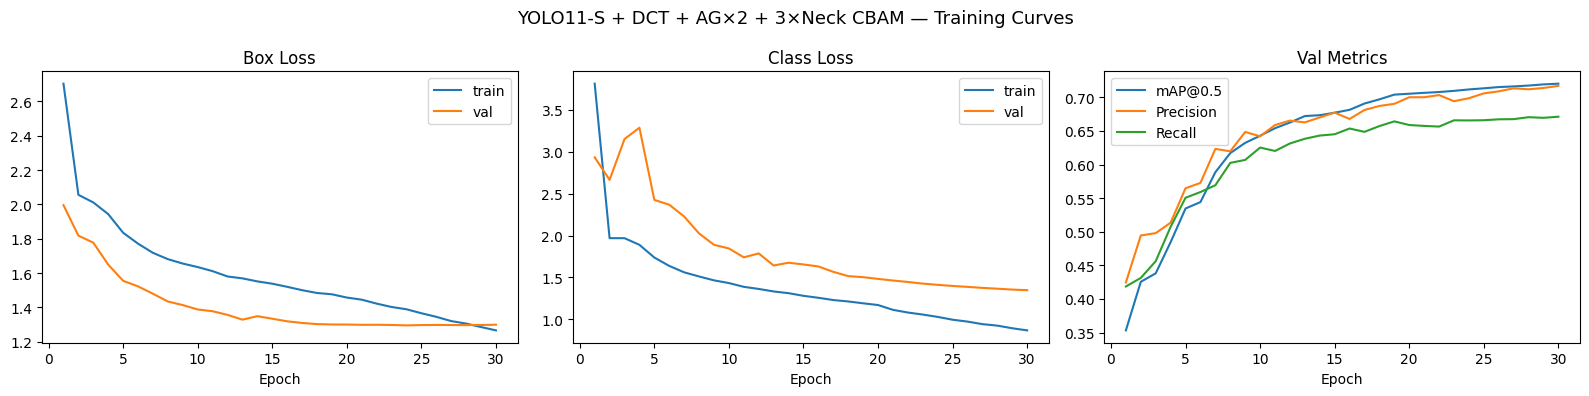

In [19]:
KS_DIR  = "/kaggle/working/runs/yolo11s_dct_ag_3cbam"
BEST_PT = f"{KS_DIR}/weights/best.pt"

df = pd.read_csv(f"{KS_DIR}/results.csv")
df.columns = df.columns.str.strip()

print("── Per-epoch summary ──────────────────────────────────────────")
print(df[["epoch",
          "train/box_loss", "val/box_loss",
          "metrics/mAP50(B)",
          "metrics/precision(B)",
          "metrics/recall(B)"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO11-S + DCT + AG×2 + 3×Neck CBAM — Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/yolo11s_dct_ag_3cbam_curves.png", dpi=120)
plt.show()

---
## 13. Evaluation

Three evaluation passes — identical methodology to all previous ablations:
- **Eval A** — D-Fire test set (3,754 images) — cross-dataset generalization
- **Eval B** — Combined val set (7,025 images) — all three source distributions
- **Eval C** — PyroNear val only — tower camera FP rate + image-level recall

In [20]:
try:
    del ks_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

eval_model = YOLO(BEST_PT)
lbl_test   = Path(f"{UNIFIED}/labels/test")
img_test   = Path(f"{UNIFIED}/images/test")
lbl_val    = Path(f"{UNIFIED}/labels/val")
img_val    = Path(f"{UNIFIED}/images/val")


def batched_fp_rate(model, hard_neg_imgs, batch_size=200):
    """Compute FP rate on hard negative images in batches to avoid OOM."""    
    fp = 0
    for i in range(0, len(hard_neg_imgs), batch_size):
        preds = model.predict(source=hard_neg_imgs[i:i+batch_size],
                              imgsz=640, conf=0.25, device=0, verbose=False)
        fp += sum(1 for r in preds if len(r.boxes) > 0)
        torch.cuda.empty_cache()
    return fp, fp / len(hard_neg_imgs) if hard_neg_imgs else 0


def get_hard_negs(img_dir, lbl_dir):
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in lbl_dir.glob("*.txt")
        if lbl.read_text().strip() == ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

VRAM free: 15.3 GB ✅


In [21]:
# ════════════════════════════════════════════════════════════════════
# EVAL A — D-Fire Test Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL A: D-Fire Test Set ────────────────────────────────────")
metrics_A = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "test",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = KS_DIR,
    name     = "eval_A_dfire_test",
    exist_ok = True,
)

map50_A, map5095_A = metrics_A.box.map50, metrics_A.box.map
prec_A,  rec_A     = metrics_A.box.mp,    metrics_A.box.mr

print(f"  mAP@0.5      : {map50_A:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_A:.4f}")
print(f"  Precision    : {prec_A:.4f}")
print(f"  Recall       : {rec_A:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_A.box.ap50[i]:.4f}")

hard_neg_A       = get_hard_negs(img_test, lbl_test)
fp_A, fp_rate_A  = batched_fp_rate(eval_model, hard_neg_A)
print(f"\n  Hard negatives : {len(hard_neg_A)}")
print(f"  False positives: {fp_A}")
print(f"  FP Rate        : {fp_rate_A:.4f} ({fp_rate_A*100:.1f}%)")

── EVAL A: D-Fire Test Set ────────────────────────────────────
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_dct_ag_3cbam summary (fused): 141 layers, 9,654,252 parameters, 0 gradients, 22.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8.6±4.3 MB/s, size: 102.6 KB)
val: Scanning /kaggle/working/unified_dataset/labels/test... 3754 images, 2005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3754/3754 670.6it/s 5.6s
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11243.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11244.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11245.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11313.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11315.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unif

In [22]:
# ════════════════════════════════════════════════════════════════════
# EVAL B — Combined Val Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL B: Combined Val Set ───────────────────────────────────")
torch.cuda.empty_cache()
metrics_B = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "val",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = KS_DIR,
    name     = "eval_B_combined_val",
    exist_ok = True,
)

map50_B, map5095_B = metrics_B.box.map50, metrics_B.box.map
prec_B,  rec_B     = metrics_B.box.mp,    metrics_B.box.mr

print(f"  mAP@0.5      : {map50_B:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_B:.4f}")
print(f"  Precision    : {prec_B:.4f}")
print(f"  Recall       : {rec_B:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_B.box.ap50[i]:.4f}")

hard_neg_B       = get_hard_negs(img_val, lbl_val)
fp_B, fp_rate_B  = batched_fp_rate(eval_model, hard_neg_B)
print(f"\n  Hard negatives : {len(hard_neg_B)}")
print(f"  False positives: {fp_B}")
print(f"  FP Rate        : {fp_rate_B:.4f} ({fp_rate_B*100:.1f}%)")

── EVAL B: Combined Val Set ───────────────────────────────────
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1480.5±1015.5 MB/s, size: 187.1 KB)
val: Scanning /kaggle/working/unified_dataset/labels/val.cache... 7025 images, 2129 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7025/7025 2.9Git/s 0.0s
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07536.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07539.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07561.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 879/879 13.6it/s 1:05
                   all       7025       7079      0.719      0.673       0.72      0.412
                 smoke       4733       5668      0.708      0.711      0.734      0.445
         

In [23]:
# ════════════════════════════════════════════════════════════════════
# EVAL C — PyroNear Val Only (tower cameras, in-distribution)
# ════════════════════════════════════════════════════════════════════
print("── EVAL C: PyroNear Val (tower cameras) ───────────────────────")
pyro_val_imgs = sorted(img_val.glob("pyro_*.jpg"))
pyro_val_lbls = [lbl_val / p.with_suffix(".txt").name for p in pyro_val_imgs]
pyro_pos      = sum(1 for l in pyro_val_lbls if l.exists() and l.read_text().strip())
pyro_neg      = sum(1 for l in pyro_val_lbls if l.exists() and not l.read_text().strip())
print(f"  Total images    : {len(pyro_val_imgs)}")
print(f"  Positives       : {pyro_pos}")
print(f"  Hard negatives  : {pyro_neg}")

tp_C = fp_C = fn_C = 0
BATCH = 200
for i in range(0, len(pyro_val_imgs), BATCH):
    chunk_imgs = [str(p) for p in pyro_val_imgs[i:i+BATCH]]
    chunk_lbls = pyro_val_lbls[i:i+BATCH]
    preds = eval_model.predict(source=chunk_imgs, imgsz=640,
                               conf=0.25, device=0, verbose=False)
    for pred, lbl_path in zip(preds, chunk_lbls):
        has_gt  = lbl_path.exists() and lbl_path.read_text().strip() != ""
        has_det = len(pred.boxes) > 0
        if     has_gt and     has_det: tp_C += 1
        elif   has_gt and not has_det: fn_C += 1
        elif not has_gt and   has_det: fp_C += 1
    torch.cuda.empty_cache()

fp_rate_C = fp_C / pyro_neg if pyro_neg else 0
recall_C  = tp_C / pyro_pos if pyro_pos else 0
print(f"\n  True Positives     : {tp_C}")
print(f"  False Positives    : {fp_C}")
print(f"  False Negatives    : {fn_C}")
print(f"  FP Rate            : {fp_rate_C:.4f} ({fp_rate_C*100:.1f}%)")
print(f"  Image-level Recall : {recall_C:.4f} ({recall_C*100:.1f}%)")

── EVAL C: PyroNear Val (tower cameras) ───────────────────────
  Total images    : 4099
  Positives       : 3345
  Hard negatives  : 754

  True Positives     : 2968
  False Positives    : 443
  False Negatives    : 377
  FP Rate            : 0.5875 (58.8%)
  Image-level Recall : 0.8873 (88.7%)


---
## 14. Results Summary & Save

In [24]:
print("\n" + "="*70)
print(" RESULTS — YOLO11-S + DCT + AG×2 + 3×Neck CBAM  (kitchen sink)")
print("="*70)
print(f"  {'Eval':<38} {'mAP@0.5':>8} {'Prec':>8} {'Rec':>8} {'FP Rate':>8}")
print(f"  {'-'*70}")
print(f"  {'A: D-Fire test  (cross-dataset)':<38} {map50_A:>8.4f} {prec_A:>8.4f} {rec_A:>8.4f} {fp_rate_A:>8.4f}")
print(f"  {'B: Combined val (all datasets)':<38} {map50_B:>8.4f} {prec_B:>8.4f} {rec_B:>8.4f} {fp_rate_B:>8.4f}")
print(f"  {'C: PyroNear val (tower only)':<38} {'—':>8} {'—':>8} {recall_C:>8.4f} {fp_rate_C:>8.4f}")
print("="*70)

# ── Ablation comparison context ─────────────────────────────────────
print("\n── Ablation Table Context ─────────────────────────────────────────────────")
ablation = [
    ("Baseline",           0.7653, 0.6835, 1.70, 0.7344, 0.8852, 0.6074),
    ("1×CBAM SPPF",        0.7550, 0.6736, 2.19, 0.7308, 0.9046, 0.6008),
    ("3×CBAM Neck",        0.7409, 0.6708, 1.20, 0.7200, 0.8251, 0.4231),
    ("4×CBAM (SPPF+3×N)",  0.7574, 0.6873, 2.19, 0.7328, 0.9136, 0.5889),
    ("2×CBAM (SPPF+P4)",   0.7655, 0.6931, 1.85, 0.7306, 0.8957, 0.5915),
    ("AG Skips (#2)",      0.7515, 0.6804, 1.05, 0.7236, 0.8921, 0.5623),
    ("CA+CBAM (#4)",       0.7583, 0.6895, 1.75, 0.7310, 0.9157, 0.6154),
    ("DCT Freq. Attn (#3)",0.7652, 0.6853, 1.75, 0.7333, 0.9133, 0.6167),
]
print(f"  {'Config':<28} {'mAP-D':>7} {'Rec-D':>7} {'FP-D':>6} {'mAP-C':>7} {'Rec-P':>7} {'FP-P':>6}")
print(f"  {'-'*68}")
for row in ablation:
    name, ma, rc, fp, mc, rp, fpp = row
    print(f"  {name:<28} {ma:>7.4f} {rc:>7.4f} {fp:>5.1f}% {mc:>7.4f} {rp:>7.4f} {fpp*100:>5.1f}%")
print(f"  {'─'*68}")
print(f"  {'DCT+AG+3×CBAM (THIS RUN)':<28} {map50_A:>7.4f} {rec_A:>7.4f} {fp_rate_A*100:>5.1f}% {map50_B:>7.4f} {recall_C:>7.4f} {fp_rate_C*100:>5.1f}%")
print()

ks_results = {
    "model"                   : "YOLO11-S + DCT + AG×2 + 3×Neck CBAM",
    "train_data"              : "unified (55,698)",
    "params"                  : "~9.4M + DCT + AG×2 + CBAM×3",
    # Eval A
    "mAP50_dfire_test"        : round(float(map50_A),    4),
    "mAP5095_dfire_test"      : round(float(map5095_A),  4),
    "precision_dfire_test"    : round(float(prec_A),     4),
    "recall_dfire_test"       : round(float(rec_A),      4),
    "fp_rate_dfire_test"      : round(float(fp_rate_A),  4),
    "ap50_smoke_dfire"        : round(float(metrics_A.box.ap50[0]), 4),
    "ap50_fire_dfire"         : round(float(metrics_A.box.ap50[1]), 4),
    # Eval B
    "mAP50_combined_val"      : round(float(map50_B),    4),
    "mAP5095_combined_val"    : round(float(map5095_B),  4),
    "precision_combined_val"  : round(float(prec_B),     4),
    "recall_combined_val"     : round(float(rec_B),      4),
    "fp_rate_combined_val"    : round(float(fp_rate_B),  4),
    "ap50_smoke_combined"     : round(float(metrics_B.box.ap50[0]), 4),
    "ap50_fire_combined"      : round(float(metrics_B.box.ap50[1]), 4),
    # Eval C
    "recall_pyronear_val"     : round(float(recall_C),   4),
    "fp_rate_pyronear_val"    : round(float(fp_rate_C),  4),
    "tp_pyronear"             : int(tp_C),
    "fp_pyronear"             : int(fp_C),
    "fn_pyronear"             : int(fn_C),
}

results_csv = "/kaggle/working/yolo11s_dct_ag_3cbam_results.csv"
pd.DataFrame([ks_results]).to_csv(results_csv, index=False)
print(f"Results saved → {results_csv} ✅")

for k, v in ks_results.items():
    print(f"  {k:<35}: {v}")


 RESULTS — YOLO11-S + DCT + AG×2 + 3×Neck CBAM  (kitchen sink)
  Eval                                    mAP@0.5     Prec      Rec  FP Rate
  ----------------------------------------------------------------------
  A: D-Fire test  (cross-dataset)          0.7489   0.7382   0.6858   0.0204
  B: Combined val (all datasets)           0.7203   0.7187   0.6729   0.2189
  C: PyroNear val (tower only)                  —        —   0.8873   0.5875

── Ablation Table Context ─────────────────────────────────────────────────
  Config                         mAP-D   Rec-D   FP-D   mAP-C   Rec-P   FP-P
  --------------------------------------------------------------------
  Baseline                      0.7653  0.6835   1.7%  0.7344  0.8852  60.7%
  1×CBAM SPPF                   0.7550  0.6736   2.2%  0.7308  0.9046  60.1%
  3×CBAM Neck                   0.7409  0.6708   1.2%  0.7200  0.8251  42.3%
  4×CBAM (SPPF+3×N)             0.7574  0.6873   2.2%  0.7328  0.9136  58.9%
  2×CBAM (SPPF+P4)    

In [25]:
# ── Final zip of all outputs ──────────────────────────────────────────────────
shutil.make_archive("/kaggle/working/yolo11s_dct_ag_3cbam_full", "zip",
                    "/kaggle/working/runs/yolo11s_dct_ag_3cbam")
print("Full run directory zipped → yolo11s_dct_ag_3cbam_full.zip ✅")

print("\nSaved files:")
for f in sorted(Path(KS_DIR).rglob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024 / 1024
        print(f"  {f.relative_to(KS_DIR)} ({size:.1f} MB)")

Full run directory zipped → yolo11s_dct_ag_3cbam_full.zip ✅

Saved files:
  BoxF1_curve.png (0.1 MB)
  BoxPR_curve.png (0.1 MB)
  BoxP_curve.png (0.1 MB)
  BoxR_curve.png (0.1 MB)
  args.yaml (0.0 MB)
  confusion_matrix.png (0.1 MB)
  confusion_matrix_normalized.png (0.1 MB)
  eval_A_dfire_test/BoxF1_curve.png (0.1 MB)
  eval_A_dfire_test/BoxPR_curve.png (0.1 MB)
  eval_A_dfire_test/BoxP_curve.png (0.1 MB)
  eval_A_dfire_test/BoxR_curve.png (0.1 MB)
  eval_A_dfire_test/confusion_matrix.png (0.1 MB)
  eval_A_dfire_test/confusion_matrix_normalized.png (0.1 MB)
  eval_A_dfire_test/val_batch0_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch0_pred.jpg (0.2 MB)
  eval_A_dfire_test/val_batch1_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch1_pred.jpg (0.2 MB)
  eval_A_dfire_test/val_batch2_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch2_pred.jpg (0.2 MB)
  eval_B_combined_val/BoxF1_curve.png (0.1 MB)
  eval_B_combined_val/BoxPR_curve.png (0.1 MB)
  eval_B_combined_val/BoxP_curve.png (0.1

In [26]:
import shutil
import os

print("── Starting Final Cleanup ──────────────────────────")
directories_to_delete = [
    "/kaggle/working/unified_dataset",
    "/kaggle/working/pyro_yolo",
    "/kaggle/working/nemo_yolo"
]

for dir_path in directories_to_delete:
    if os.path.exists(dir_path):
        print(f"Deleting {dir_path}...")
        shutil.rmtree(dir_path)

print("Cleanup complete! Your Kaggle output will be lightweight. ✅")

── Starting Final Cleanup ──────────────────────────
Deleting /kaggle/working/unified_dataset...
Deleting /kaggle/working/pyro_yolo...
Deleting /kaggle/working/nemo_yolo...
Cleanup complete! Your Kaggle output will be lightweight. ✅
